## BERT

In [ ]:
# BertTokenizer: for converting raw text into token IDs.
# BertForSequenceClassification: pretrained BERT model for classification tasks.
# torch: needed to handle tensors and use the model with PyTorch.

from transformers import BertTokenizer, BertForSequenceClassification
import torch



# Loads the pre-trained tokenizer for bert-base-uncased from HuggingFace’s model hub.
# This tokenizer:
# Converts words to tokens (subword units).
# Adds special tokens like [CLS] and [SEP].
# Converts tokens to integers (token IDs).

# Load tokenizer and model
# tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Load base BERT with more number of labels
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")




# Loads a BERT model fine-tuned for sentiment classification (on the IMDB dataset).
# This model predicts whether a review is positive (1) or negative (0).
# model = BertForSequenceClassification.from_pretrained("textattack/bert-base-uncased-imdb")  # pretrained for sentiment



# Put model in eval mode
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
# Inference

text = "I am enjoying doing the ISI research internship!"

# Tokenizes the input text and returns:
# input_ids: the numerical representation of tokens.
# attention_mask: indicates which tokens are real and which are padding.
# return_tensors="pt" returns results as PyTorch tensors.
# truncation=True, padding=True make sure the sequence is of proper length.

inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

# Turns off gradient tracking (since we don’t need to train), and passes inputs through the model.
with torch.no_grad():
    outputs = model(**inputs)
    # logits are raw scores (not probabilities).
    # We take the argmax (index of highest score) to get the predicted class label:
    # 1 = positive
    # 0 = negative
    logits = outputs.logits
    predicted_class = torch.argmax(logits, dim=1).item()

print("Predicted label:", predicted_class)  # 1 = positive, 0 = negative

Predicted label: 1


## RoBERTa

In [ ]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import torch

# Load tokenizer and model
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
model = RobertaForSequenceClassification.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment")  # 3-class sentiment

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [ ]:
# Inference
text = "I go"
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
with torch.no_grad():
    outputs = model(**inputs)
    predicted_class = torch.argmax(outputs.logits, dim=1).item()

# Labels: 0 = negative, 1 = neutral, 2 = positive
labels = ["Negative", "Neutral", "Positive"]
print("Predicted:", labels[predicted_class])

Predicted: Neutral


## Inception V3

In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 121.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 112.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 124.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.31.1
    Uninstalling protobuf-6.31.1:
      Successfully uninstalled protobuf-6.31.1


In [ ]:
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np

# Load model
model = InceptionV3(weights='imagenet')

### Positive

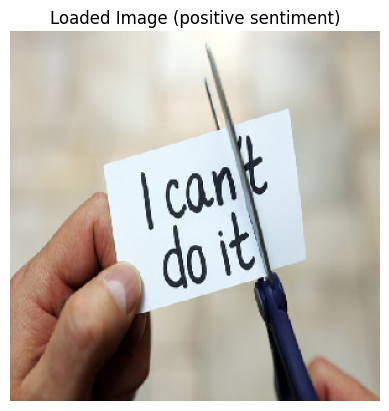

In [ ]:
# Load image and preprocess
pos_img_path = 'positive.jpg'
pos_img = image.load_img(pos_img_path, target_size=(299, 299))

import matplotlib.pyplot as plt
# Display image
plt.imshow(pos_img)
plt.axis('off')  # Hides axis labels
plt.title("Loaded Image (positive sentiment)")
plt.show()

In [ ]:
pos_x = image.img_to_array(pos_img)
pos_x = np.expand_dims(pos_x, axis=0)
pos_x = preprocess_input(pos_x)

# Inference
preds = model.predict(pos_x)
print("Predicted class:", decode_predictions(preds, top=3)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted class: [('n06794110', 'street_sign', np.float32(0.042856272)), ('n03000134', 'chainlink_fence', np.float32(0.042233735)), ('n03976657', 'pole', np.float32(0.04028749))]


### Neutral

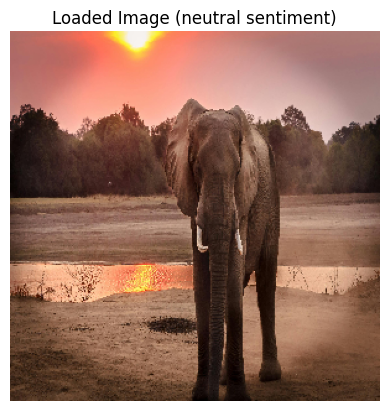

In [ ]:
# Load image and preprocess
neu_img_path = 'neutral.jpg'
neu_img = image.load_img(neu_img_path, target_size=(299, 299))

import matplotlib.pyplot as plt
# Display image
plt.imshow(neu_img)
plt.axis('off')  # Hides axis labels
plt.title("Loaded Image (neutral sentiment)")
plt.show()

In [ ]:
neu_x = image.img_to_array(neu_img)
neu_x = np.expand_dims(neu_x, axis=0)
neu_x = preprocess_input(neu_x)

# Inference
preds = model.predict(neu_x)
print("Predicted class:", decode_predictions(preds, top=3)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step
Predicted class: [('n01871265', 'tusker', np.float32(0.7891802)), ('n02504013', 'Indian_elephant', np.float32(0.102283016)), ('n02504458', 'African_elephant', np.float32(0.04975565))]


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


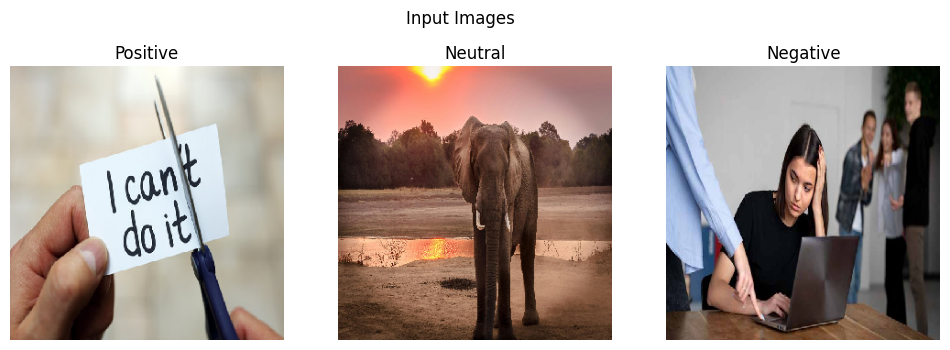


🎯 Sentiment scores for: positive.jpg
Negative: 0.5593
Neutral: 0.0692
Positive: 0.3715


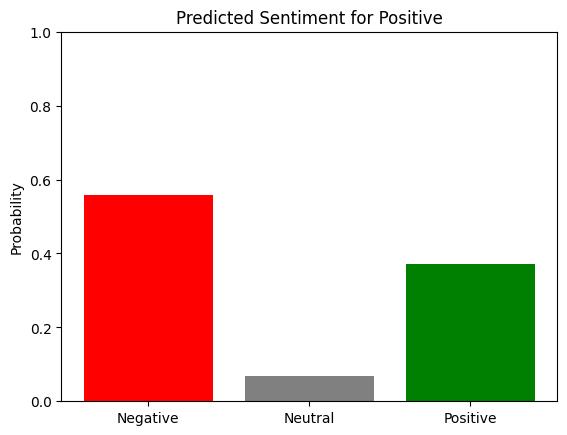


🎯 Sentiment scores for: neutral.jpg
Negative: 0.4320
Neutral: 0.2348
Positive: 0.3332


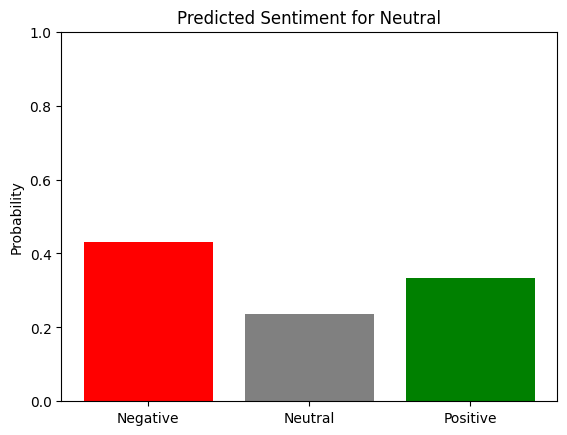


🎯 Sentiment scores for: negative.jpg
Negative: 0.6865
Neutral: 0.1245
Positive: 0.1890


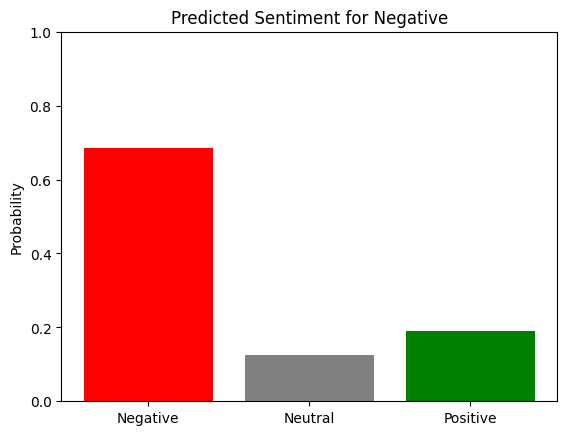

In [ ]:
# Install TensorFlow if needed (uncomment below line if running fresh)
# !pip install tensorflow

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import os

# ----- SETUP: Pretrained Inception + Custom Sentiment Head -----
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
output = Dense(3, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)

# Freeze base model layers (optional)
for layer in base_model.layers:
    layer.trainable = False

# ----- INPUT: Load 3 local images -----
img_names = ["positive.jpg", "neutral.jpg", "negative.jpg"]
img_arrays = []
original_imgs = []

for name in img_names:
    img = image.load_img(name, target_size=(299, 299))
    original_imgs.append(img)  # For display
    arr = image.img_to_array(img)
    arr = preprocess_input(arr)
    img_arrays.append(arr)

img_batch = np.stack(img_arrays)  # Shape: (3, 299, 299, 3)

# ----- INFERENCE -----
predictions = model.predict(img_batch)
sentiment_labels = ["Negative", "Neutral", "Positive"]

# ----- DISPLAY: All 3 images side by side -----
plt.figure(figsize=(12, 4))
for i, img in enumerate(original_imgs):
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(img_names[i].split('.')[0].capitalize())
    plt.axis('off')
plt.suptitle("Input Images")
plt.show()

# ----- DISPLAY: Print scores and plot bar chart for each -----
for i in range(3):
    print(f"\n🎯 Sentiment scores for: {img_names[i]}")
    for label, score in zip(sentiment_labels, predictions[i]):
        print(f"{label}: {score:.4f}")

    # Bar plot
    plt.bar(sentiment_labels, predictions[i], color=["red", "gray", "green"])
    plt.title(f"Predicted Sentiment for {img_names[i].split('.')[0].capitalize()}")
    plt.ylim([0, 1])
    plt.ylabel("Probability")
    plt.show()


## Xception

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


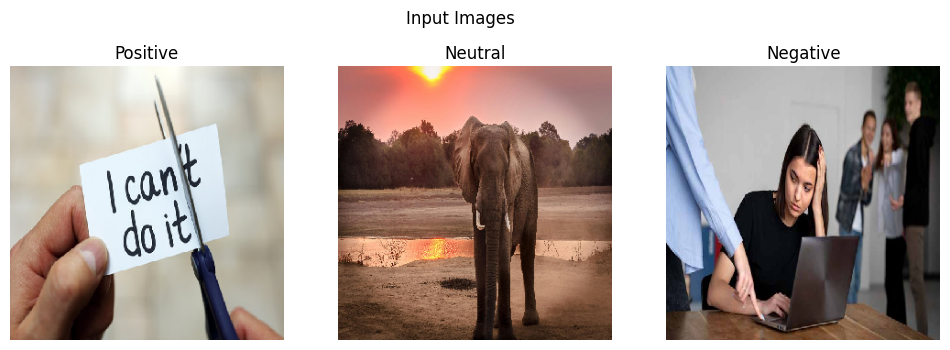

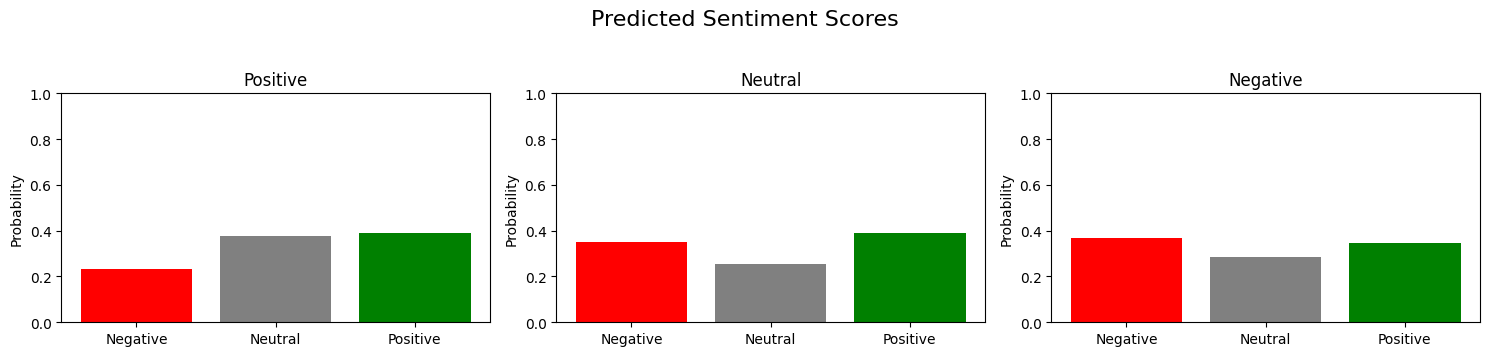


📷 Image: positive.jpg
  Negative: 0.2323
  Neutral: 0.3764
  Positive: 0.3913

📷 Image: neutral.jpg
  Negative: 0.3519
  Neutral: 0.2561
  Positive: 0.3920

📷 Image: negative.jpg
  Negative: 0.3681
  Neutral: 0.2840
  Positive: 0.3479


In [ ]:
# Install TensorFlow if not already installed
# !pip install tensorflow

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.xception import Xception, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# ----- SETUP: Pretrained Xception + Custom Sentiment Head -----
base_model = Xception(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
output = Dense(3, activation='softmax')(x)  # 3 sentiment classes: neg, neutral, pos
model = Model(inputs=base_model.input, outputs=output)

# Freeze base model layers (optional)
for layer in base_model.layers:
    layer.trainable = False

# ----- INPUT: Load 3 local images -----
img_names = ["positive.jpg", "neutral.jpg", "negative.jpg"]
img_arrays = []
original_imgs = []

for name in img_names:
    img = image.load_img(name, target_size=(299, 299))
    original_imgs.append(img)
    arr = image.img_to_array(img)
    arr = preprocess_input(arr)
    img_arrays.append(arr)

img_batch = np.stack(img_arrays)  # Shape: (3, 299, 299, 3)

# ----- INFERENCE -----
predictions = model.predict(img_batch)
sentiment_labels = ["Negative", "Neutral", "Positive"]

# ----- DISPLAY: All 3 input images in a row -----
plt.figure(figsize=(12, 4))
for i, img in enumerate(original_imgs):
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(img_names[i].split('.')[0].capitalize())
    plt.axis('off')
plt.suptitle("Input Images")
plt.show()

# ----- DISPLAY: 3 sentiment bar charts in a row -----
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for i in range(3):
    axs[i].bar(sentiment_labels, predictions[i], color=["red", "gray", "green"])
    axs[i].set_title(f"{img_names[i].split('.')[0].capitalize()}")
    axs[i].set_ylim([0, 1])
    axs[i].set_ylabel("Probability")
plt.suptitle("Predicted Sentiment Scores", fontsize=16)
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

# ----- PRINT: Sentiment scores categorically -----
for i in range(3):
    print(f"\n📷 Image: {img_names[i]}")
    for label, score in zip(sentiment_labels, predictions[i]):
        print(f"  {label}: {score:.4f}")


# New Model trials
**TSA Channel** models for testing:


1.   RoBERTa
2.   BART
3.   DeBERTa
4.   ERNIE3.0
5.   T5

**VSA Channel** models for testing:
1.   EmoNET
2.   SentiGAN
3.   CLIP
4.   ViT-L

**MSA Channel** models for testing:
1.   BLIP-2-VSA
2.   VisualBERT
3.   Kosmos-2

## TSA Channel

### RoBERTa